In [2]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from groq import RateLimitError, APIError, APIConnectionError
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition
from functools import partial
from prompts import SYSTEM_PROMPT
from tools import calculator, rag_tool, web_search
from llm_router import invoke_with_fallback, MODEL_CHAIN
from pydantic import BaseModel, Field
from langchain_core.prompts import PromptTemplate
from chat_app_backend_rag import llm_structured
import tqdm as notebook_tqdm


In [2]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import os

load_dotenv()

groq = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,
    groq_api_key=os.getenv("GROQ_API_KEY"),
    disable_streaming=True, max_tokens=512
)

In [3]:
groq.invoke("hi")

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond appropriately. It\'s a simple greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 72, 'total_tokens': 113, 'completion_time': 0.085872695, 'completion_tokens_details': {'reasoning_tokens': 23}, 'prompt_time': 0.0152284, 'prompt_tokens_details': None, 'queue_time': 0.395048697, 'total_time': 0.101101095}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08560-1fde-7d82-9e17-dfbb9fe80d20-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 41, 'total_tokens': 113, 'output_token_details': {'reasoning': 23}})

In [6]:
from chat_app_backend import graph, chat
import pytz

ModuleNotFoundError: No module named 'pytz'

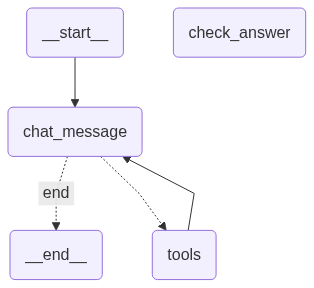

In [ ]:
chat

In [16]:
from langchain_groq import ChatGroq
import os
llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model = 'openai/gpt-oss-20b',
    temperature=0.7,
)

llm.invoke("Hello, how are you?")


AIMessage(content="Hello! I'm just a bundle of code, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'reasoning_content': "We need to respond politely. There's no special instructions. Just answer."}, response_metadata={'token_usage': {'completion_tokens': 55, 'prompt_tokens': 77, 'total_tokens': 132, 'completion_time': 0.059185708, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.005050722, 'prompt_tokens_details': None, 'queue_time': 0.048479048, 'total_time': 0.06423643}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e99e93f2ac', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07b12-c20e-7771-8855-b5c201febe04-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 55, 'total_tokens': 132, 'output_token_details': {'reasoning': 15}})